<a href="https://colab.research.google.com/github/carlosvasquez3/M.Sc.-in-Data-Science/blob/main/Estad%C3%ADstica/TRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
trm = pd.read_excel('Tasa de cambio del peso colombiano (19).xlsx')

In [ ]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
0,yyyy/mm/dd,COP/USD
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7


In [ ]:
trm = trm.drop(index=0)

In [ ]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7
5,1991/12/01,643.42


In [ ]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], errors='coerce')
trm = trm.dropna(subset=['Fecha'])

In [ ]:
trm

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991-11-27,693.32
2,1991-11-28,693.99
3,1991-11-29,694.7
4,1991-11-30,694.7
5,1991-12-01,643.42
...,...,...
12536,2026-03-23,3704.87
12537,2026-03-24,3704.87
12538,2026-03-25,3700.67
12539,2026-03-26,3688.46


In [ ]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], format='%Y-%m-%d')

In [ ]:
fig = px.line(trm,x ='Fecha', y='Tasa Representativa del Mercado (TRM)')
fig.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

trm_comps_add = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='additive',period= 365)

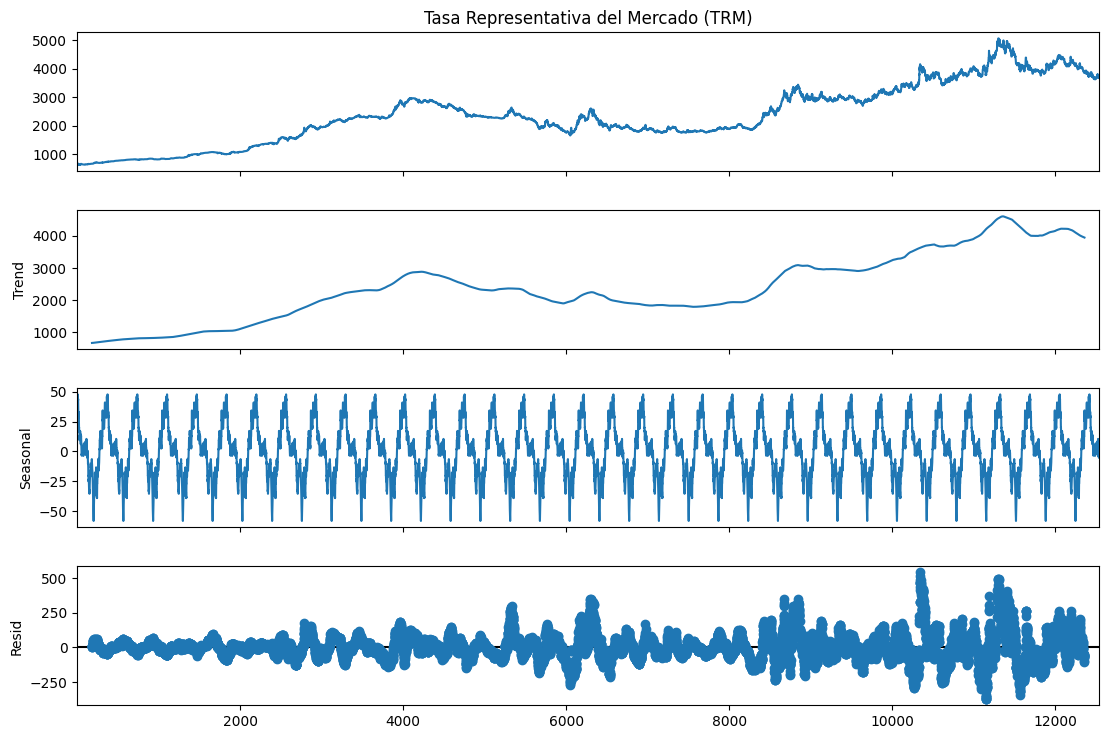

In [ ]:
fig = trm_comps_add.plot()
fig.set_size_inches((12,8))

In [ ]:
print('Promedio de los residuales (descomposición aditiva):', trm_comps_add.resid.mean())

Promedio de los residuales (descomposición aditiva): 1.233049016965317


In [ ]:
trm_comps_mult = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='multiplicative',period= 365)


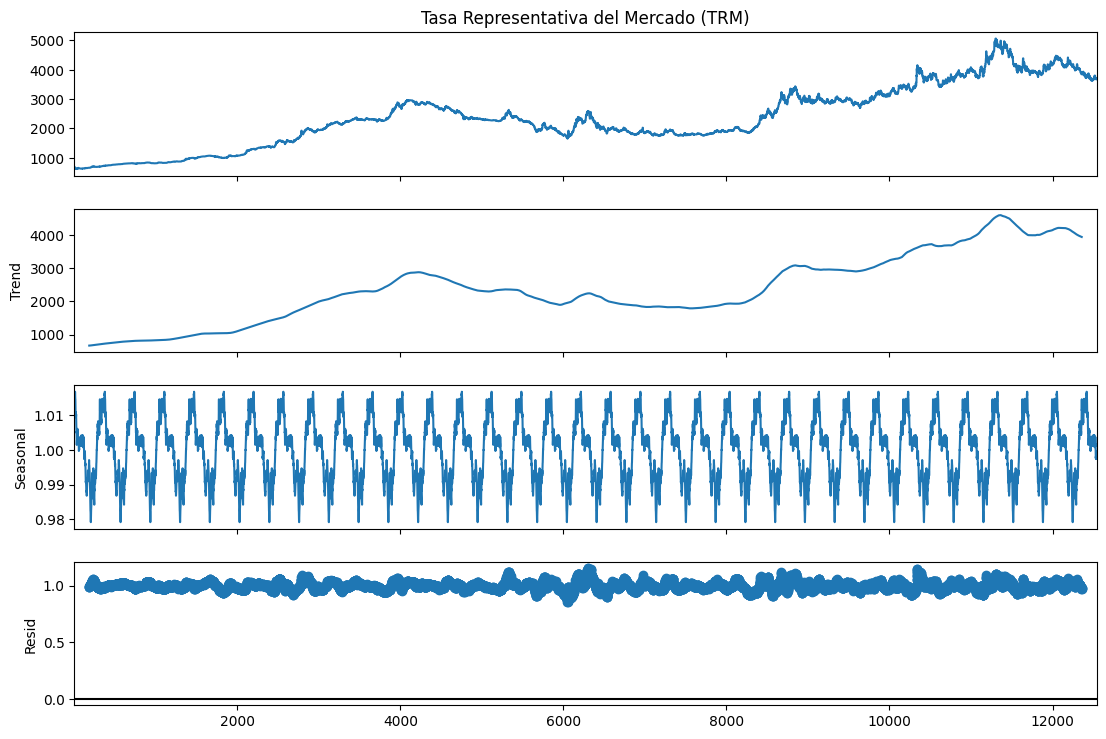

In [ ]:
fig = trm_comps_mult.plot()
fig.set_size_inches((12,8))

In [ ]:
print('Promedio de los residuales (descomposición multiplicativa):', trm_comps_mult.resid.mean())

Promedio de los residuales (descomposición multiplicativa): 0.9996869389881624


In [ ]:
from statsmodels.tsa.seasonal import STL

trm_stl = STL(trm['Tasa Representativa del Mercado (TRM)'], period=365).fit()


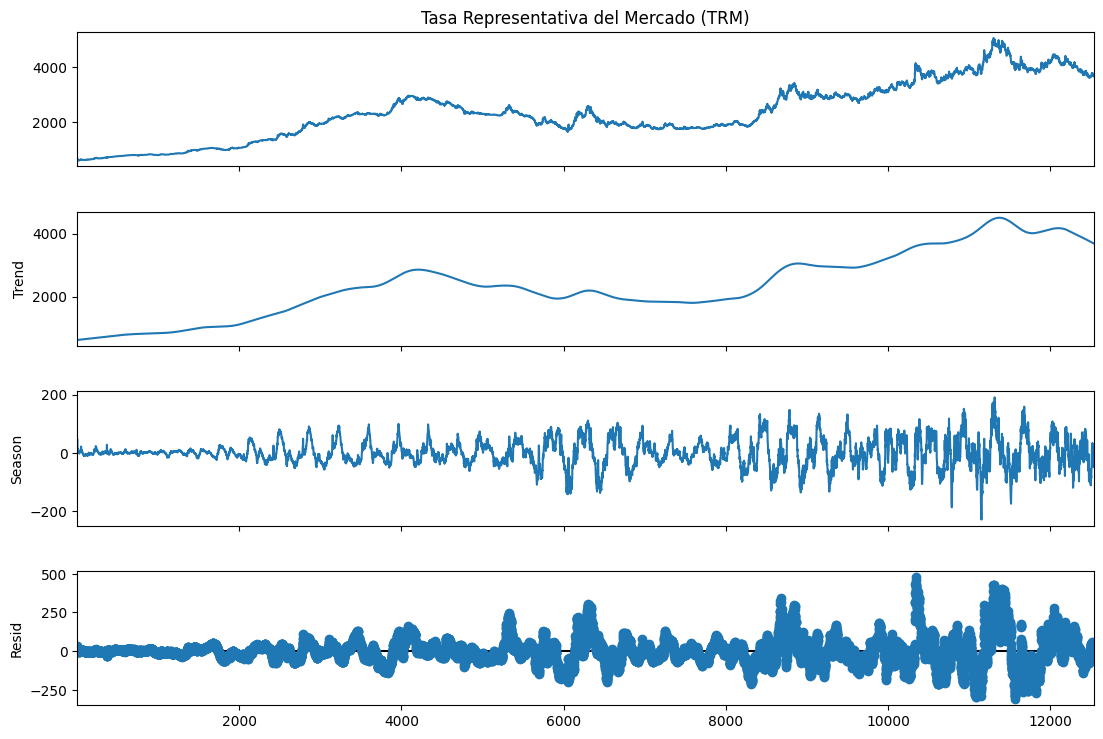

In [ ]:
fig = trm_stl.plot()
fig.set_size_inches((12,8))

In [ ]:
print('Promedio de los residuales (descomposición STL):', trm_stl.resid.mean())

Promedio de los residuales (descomposición STL): 1.157982347805179
